# Proyek Klasifikasi Gambar: Image Classification
- **Nama:** Bayu Prasetyo
- **Email:** bayupras0301@gmail.com
- **ID Dicoding:** bayupras0301
- **Dataset Link:** https://www.kaggle.com/datasets/andrewmvd/animal-faces

## Import Semua Packages/Library yang Digunakan

In [4]:
!pip -q install kagglehub tensorflowjs

import os, shutil, random, pathlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential

print("TensorFlow:", tf.__version__)
seed = 42
tf.keras.utils.set_random_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Download dataset Intel Image Classification
import kagglehub
path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Dataset path:", path)

TensorFlow: 2.19.0
Using Colab cache for faster access to the 'animal-faces' dataset.
Dataset path: /kaggle/input/animal-faces


## Data Preparation

### Data Loading

In [5]:
# 1. Pastikan variabel 'path' tersedia (diambil dari download kagglehub)
# Jika baru saja merestart runtime, jalankan kembali blok download dataset.
try:
    print(f"Menggunakan base path: {path}")
except NameError:
    import kagglehub
    path = kagglehub.dataset_download("andrewmvd/animal-faces")
    print(f"Dataset berhasil diunduh ke: {path}")

# 2. Fungsi untuk mencari folder spesifik di dalam direktori bertingkat
def find_folder(root_path, folder_name):
    for root, dirs, files in os.walk(root_path):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    return None

# Mencari lokasi folder train dan test yang sebenarnya
orig_train = find_folder(path, "train")
orig_test = find_folder(path, "val")

# 3. Pengaturan Direktori Tujuan (Merging)
base_dir = "/content/animal-faces"
all_dir = os.path.join(base_dir, "all")

# Hapus folder lama jika ingin mengulang dari awal, lalu buat folder baru
if os.path.exists(all_dir):
    shutil.rmtree(all_dir)
os.makedirs(all_dir, exist_ok=True)

# 4. Fungsi untuk menyalin data ke direktori 'all'
def copy_tree(src):
    if src is None or not os.path.exists(src):
        print(f"Peringatan: Folder sumber tidak ditemukan untuk path: {src}")
        return

    for cls in os.listdir(src):
        scls = os.path.join(src, cls)
        # Pastikan yang diproses adalah folder kelas
        if not os.path.isdir(scls):
            continue

        dcls = os.path.join(all_dir, cls)
        os.makedirs(dcls, exist_ok=True)

        for f in os.listdir(scls):
            # Hanya salin file (bukan folder di dalam folder kelas)
            src_file = os.path.join(scls, f)
            if os.path.isfile(src_file):
                shutil.copy(src_file, os.path.join(dcls, f))

# 5. Eksekusi Penggabungan
print("Sedang menyalin file, harap tunggu...")
copy_tree(orig_train)
copy_tree(orig_test)

# 6. Menampilkan Hasil Final
if os.path.exists(all_dir) and os.listdir(all_dir):
    list_kelas = os.listdir(all_dir)
    print("-" * 30)
    print("✅ BERHASIL!")
    print(f"Semua gambar digabung di: {all_dir}")
    print(f"Daftar kelas yang ditemukan: {list_kelas}")
    print(f"Total jumlah kelas: {len(list_kelas)}")
    print("-" * 30)
else:
    print("❌ GAGAL: Tidak ada data yang berhasil disalin. Periksa kembali struktur dataset.")

Menggunakan base path: /kaggle/input/animal-faces
Sedang menyalin file, harap tunggu...
------------------------------
✅ BERHASIL!
Semua gambar digabung di: /content/animal-faces/all
Daftar kelas yang ditemukan: ['dog', 'wild', 'cat']
Total jumlah kelas: 3
------------------------------


### Data Preprocessing

#### Split Dataset

In [6]:
# Stratified split: 70% train, 20% val, 10% test
from sklearn.model_selection import train_test_split

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

for d in [train_dir, val_dir, test_dir]:
    shutil.rmtree(d, ignore_errors=True)
    for cls in os.listdir(all_dir):
        os.makedirs(os.path.join(d, cls), exist_ok=True)

# Ambil semua file & label
image_paths, labels = [], []
for cls in os.listdir(all_dir):
    for f in os.listdir(os.path.join(all_dir, cls)):
        image_paths.append(os.path.join(all_dir, cls, f))
        labels.append(cls)

X = np.array(image_paths)
y = np.array(labels)

# Split berlapis (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=seed)

def move_files(X, y, target_dir):
    for p, lbl in zip(X, y):
        shutil.copy(p, os.path.join(target_dir, lbl, os.path.basename(p)))

move_files(X_train, y_train, train_dir)
move_files(X_val,   y_val,   val_dir)
move_files(X_test,  y_test,  test_dir)

print("Yeayyy, Dataset Berhasil Di Split.")

Yeayyy, Dataset Berhasil Di Split.


## Modelling

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameter Dasar
img_size = (150, 150)
batch_size = 32

# Persiapan Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,  # lebih tinggi untuk augmentasi
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,  # penambahan shear untuk augmentasi lebih
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load Generator
train_gen = train_datagen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')
val_gen   = val_datagen.flow_from_directory(val_dir,   target_size=img_size, batch_size=batch_size, class_mode='categorical')
test_gen  = test_datagen.flow_from_directory(test_dir,  target_size=img_size, batch_size=batch_size, class_mode='categorical')

# Custom Callback untuk Cek Akurasi Training & Validasi Target: 96%
class DualAccuracyCallback(tf.keras.callbacks.Callback):
    def __init__(self, target=0.96):
        super(DualAccuracyCallback, self).__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')

        # Mengecek apakah kedua akurasi sudah mencapai target
        if acc is not None and val_acc is not None:
            if acc >= self.target and val_acc >= self.target:
                print(f"\n[INFO] Target Tercapai!")
                print(f"Akurasi Training: {acc*100:.2f}% | Akurasi Validasi: {val_acc*100:.2f}%")
                self.model.stop_training = True

# Arsitektur Model
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),  # Directly use string 'relu'
    layers.MaxPooling2D(2,2),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# List Callbacks
callbacks = [
    DualAccuracyCallback(target=0.96), # Custom stop
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)
]

# Training
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=callbacks
)

# Evaluasi & Menampilkan Hasil Akhir
print("\n" + "="*30)
# Akurasi Training dari history terakhir
final_train_acc = history.history['accuracy'][-1]
print(f"Akurasi Data Training: {final_train_acc*100:.2f}%")

# Akurasi Data Test (Evaluasi Mandiri)
test_loss, test_acc = model.evaluate(test_gen)
print(f"Akurasi Data Testing:  {test_acc*100:.2f}%")
print("="*30)

Found 11291 images belonging to 3 classes.
Found 3242 images belonging to 3 classes.
Found 1597 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 102s 266ms/step - accuracy: 0.5976 - loss: 1.6051 - val_accuracy: 0.3593 - val_loss: 1.5249 - learning_rate: 1.0000e-04
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 87s 247ms/step - accuracy: 0.7538 - loss: 0.7378 - val_accuracy: 0.8470 - val_loss: 0.5050 - learning_rate: 1.0000e-04
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 88s 249ms/step - accuracy: 0.8048 - loss: 0.5707 - val_accuracy: 0.8840 - val_loss: 0.3728 - learning_rate: 1.0000e-04
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 88s 249ms/step - accuracy: 0.8390 - loss: 0.4995 - val_accuracy: 0.8874 - val_loss: 0.3962 - learning_rate: 1.0000e-04
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 88s 249ms/step - accuracy: 0.8589 - loss: 0.4285 - val_accuracy: 0.9112 - val_loss: 0.2794 - learning_rate: 1.0000e-04
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 87s 247ms/step - accuracy: 0.8779 - loss: 0.3693 - val_accuracy: 0.8196 - val_loss: 0.7489 - learning_rate: 1.0000e-04
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━

## Evaluasi dan Visualisasi

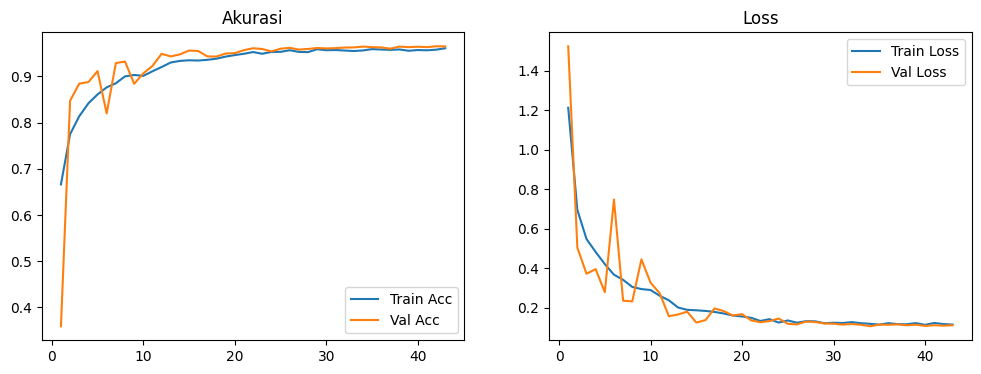

In [9]:
# Ambil akurasi dan loss dari hasil pelatihan dan validasi
acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']

# Tentukan rentang epoch
epochs = range(1, len(acc) + 1)

# Buat figur untuk plot dengan ukuran 12x4 inci
plt.figure(figsize=(12, 4))

# Plot pertama: Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.legend()
plt.title('Akurasi')

# Plot kedua: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')

# Tampilkan plot
plt.show()

## Konversi Model

In [25]:
import os
import tensorflow as tf
import tensorflowjs as tfjs

# 1. Membuat folder utama submission
os.makedirs("submission", exist_ok=True)

# --- SIMPAN DALAM FORMAT SAVEDMODEL (.pb & variables) ---
# Menggunakan model.export akan otomatis membuat folder, .pb file, dan subfolder variables
model.export("submission/saved_model")
print("✅ SavedModel (.pb & variables) tersimpan di folder 'submission/saved_model'.")

# --- SIMPAN DALAM FORMAT TF LITE ---
# Kita ambil dari folder SavedModel yang baru saja dibuat agar lebih konsisten
converter = tf.lite.TFLiteConverter.from_saved_model("submission/saved_model")
tflite_model = converter.convert()
with open("submission/model.tflite", "wb") as f:
    f.write(tflite_model)
print("✅ Model TFLite tersimpan di 'submission/model.tflite'.")

# --- SIMPAN DALAM FORMAT TENSORFLOW.JS ---
# Membuat folder khusus untuk TFJS
os.makedirs("submission/tfjs_model", exist_ok=True)
tfjs.converters.save_keras_model(model, "submission/tfjs_model")
print("✅ Model TFJS tersimpan di folder 'submission/tfjs_model'.")

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139327010565456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139327010568720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139327010568912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139327010570064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139327010569296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139327010567952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139327010569680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139327010569104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139327010567376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139326818043088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13932701

✅ Model TFLite tersimpan di 'submission/model.tflite'.
failed to lookup keras version from the file,
    this is likely a weight only file
✅ Model TFJS tersimpan di folder 'submission/tfjs_model'.


In [26]:
# Mengimpor modul yang diperlukan
import shutil
from google.colab import files

# Mengompres folder menjadi file zip
shutil.make_archive('/content/submission', 'zip', 'submission')

# Mengunduh file zip
files.download('/content/submission.zip')

# Keterangan bahwa unduhan berhasil
print("✅ Unduhan berhasil! File submission.zip telah diunduh.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Unduhan berhasil! File submission.zip telah diunduh.


## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


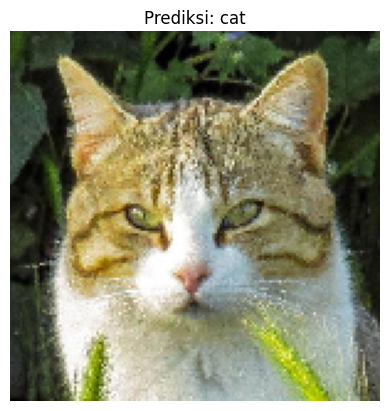

Prediksi label: cat


In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image

# Testing path direktori dataset
base_dir = "/content/animal-faces/test"

# Tentukan ukuran gambar yang sesuai dengan model
img_size = (150, 150)

# Tentukan folder spesifik untuk memilih gambar
folder_name = 'cat'  # Ganti dengan nama folder yang diinginkan, misalnya 'cat'

# Daftar kelas (label) yang digunakan dalam model
labels = ['cat', 'dog', 'wild']

# Ambil semua gambar di dalam folder 'cat'
folder_path = os.path.join(base_dir, folder_name)
image_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

# Pilih gambar acak dari folder
sample_img_path = os.path.join(folder_path, random.choice(image_files))

# Memuat dan memproses gambar
img = image.load_img(sample_img_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.  # Normalisasi gambar
img_array = np.expand_dims(img_array, axis=0)  # Menambah batch dimensi

# Prediksi dengan model
pred = model.predict(img_array)
class_idx = np.argmax(pred, axis=1)[0]  # Mendapatkan indeks kelas dengan probabilitas tertinggi
label = labels[class_idx]  # Menyusun label berdasarkan indeks kelas

# Menampilkan gambar dengan prediksi
plt.imshow(img)
plt.title(f"Prediksi: {label}")
plt.axis("off")  # Menghilangkan axis
plt.show()

# Menampilkan hasil prediksi
print(f"Prediksi label: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


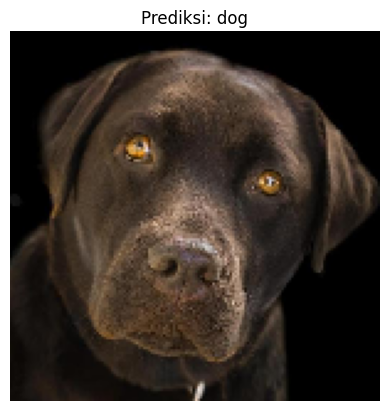

Prediksi label: dog


In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image

# Testing path direktori dataset
base_dir = "/content/animal-faces/test"

# Tentukan ukuran gambar yang sesuai dengan model
img_size = (150, 150)

# Tentukan folder spesifik untuk memilih gambar
folder_name = 'dog'  # Ganti dengan nama folder yang diinginkan, misalnya 'dog'

# Daftar kelas (label) yang digunakan dalam model
labels = ['cat', 'dog', 'wild']

# Ambil semua gambar di dalam folder 'dog'
folder_path = os.path.join(base_dir, folder_name)
image_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

# Pilih gambar acak dari folder
sample_img_path = os.path.join(folder_path, random.choice(image_files))

# Memuat dan memproses gambar
img = image.load_img(sample_img_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.  # Normalisasi gambar
img_array = np.expand_dims(img_array, axis=0)  # Menambah batch dimensi

# Prediksi dengan model
pred = model.predict(img_array)
class_idx = np.argmax(pred, axis=1)[0]  # Mendapatkan indeks kelas dengan probabilitas tertinggi
label = labels[class_idx]  # Menyusun label berdasarkan indeks kelas

# Menampilkan gambar dengan prediksi
plt.imshow(img)
plt.title(f"Prediksi: {label}")
plt.axis("off")  # Menghilangkan axis
plt.show()

# Menampilkan hasil prediksi
print(f"Prediksi label: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


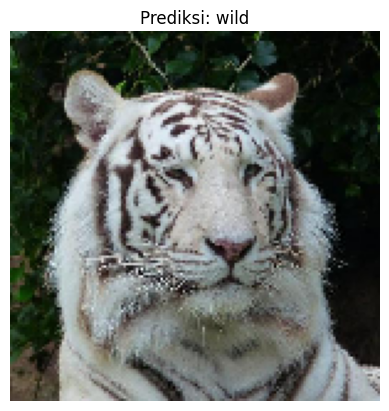

Prediksi label: wild


In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image

# Testing path direktori dataset
base_dir = "/content/animal-faces/test"

# Tentukan ukuran gambar yang sesuai dengan model
img_size = (150, 150)

# Tentukan folder spesifik untuk memilih gambar
folder_name = 'wild'  # Ganti dengan nama folder yang diinginkan, misalnya 'wild'

# Daftar kelas (label) yang digunakan dalam model
labels = ['cat', 'dog', 'wild']

# Ambil semua gambar di dalam folder 'wild'
folder_path = os.path.join(base_dir, folder_name)
image_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

# Pilih gambar acak dari folder
sample_img_path = os.path.join(folder_path, random.choice(image_files))

# Memuat dan memproses gambar
img = image.load_img(sample_img_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.  # Normalisasi gambar
img_array = np.expand_dims(img_array, axis=0)  # Menambah batch dimensi

# Prediksi dengan model
pred = model.predict(img_array)
class_idx = np.argmax(pred, axis=1)[0]  # Mendapatkan indeks kelas dengan probabilitas tertinggi
label = labels[class_idx]  # Menyusun label berdasarkan indeks kelas

# Menampilkan gambar dengan prediksi
plt.imshow(img)
plt.title(f"Prediksi: {label}")
plt.axis("off")  # Menghilangkan axis
plt.show()

# Menampilkan hasil prediksi
print(f"Prediksi label: {label}")

In [43]:
# Pembuatan requirements.txt
# Import os untuk pengecekan file
import os

# Menulis dependencies ke dalam requirements.txt menggunakan pip freeze
!pip freeze > requirements.txt

# Mengecek apakah file requirements.txt berhasil dibuat
if os.path.exists("requirements.txt"):
    print("requirements.txt berhasil dibuat")
else:
    print("Terjadi kesalahan dalam pembuatan requirements.txt")

requirements.txt berhasil dibuat
